# Laboratorio 2. Deep Learning para Series de Tiempo

## Modelado LSTM de la serie frontera La Aurora

**CC3084 - Data Science - UVG - Semestre II 2026**

**Autor:** Fernando Rueda - 23748

Se modela la serie mensual **frontera La Aurora** del Laboratorio 1 con dos
configuraciones de red LSTM y tuneo de hiperparámetros, usando **los mismos
conjuntos de entrenamiento y prueba** de ese laboratorio (70% inicial para
entrenar, 30% final para probar).

Configuraciones:

- **Config A:** LSTM de una capa con Dropout de 0.2 como regularización + capa densa de salida.
- **Config B:** LSTM bidireccional de una capa + capa densa de salida.

El tuneo recorre una rejilla de tamaño de ventana (lookback), unidades y tasa
de aprendizaje. La selección se hace por RMSE sobre un tramo de **validación
temporal** (el 15% final del entrenamiento): la prueba nunca participa en el
tuneo, solo en la evaluación final.

In [1]:
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Silencia los avisos de retracing de tf.function, son de rendimiento no de correccion
import logging
tf.get_logger().setLevel(logging.ERROR)

SEED = 23748
tf.keras.utils.set_random_seed(SEED)

plt.rcParams["figure.figsize"] = (11, 4)

## 1. Carga de los conjuntos del Laboratorio 1

`series_train.csv` y `series_test.csv` son la salida exacta de la etapa 6 del
pipeline del Laboratorio 1 (partición temporal 70/30, corte 2021-03 / 2021-04).

Entrenamiento: 147 meses, 2009-01 a 2021-03
Prueba:        63 meses, 2021-04 a 2026-06


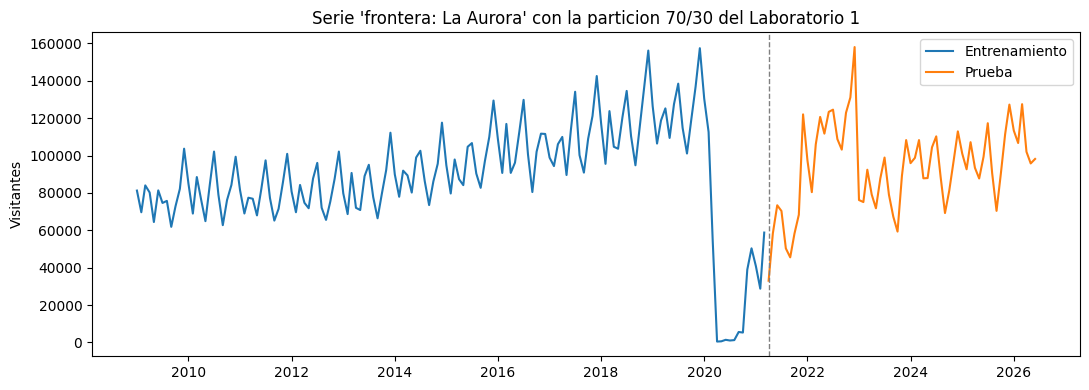

In [2]:
SERIE = "frontera: La Aurora"

train_df = pd.read_csv("../data/processed/series_train.csv", parse_dates=["fecha"])
test_df = pd.read_csv("../data/processed/series_test.csv", parse_dates=["fecha"])

train = train_df.set_index("fecha")[SERIE].astype(float)
test = test_df.set_index("fecha")[SERIE].astype(float)

print(f"Entrenamiento: {len(train)} meses, {train.index.min():%Y-%m} a {train.index.max():%Y-%m}")
print(f"Prueba:        {len(test)} meses, {test.index.min():%Y-%m} a {test.index.max():%Y-%m}")

fig, ax = plt.subplots()
ax.plot(train.index, train.values, label="Entrenamiento")
ax.plot(test.index, test.values, label="Prueba", color="tab:orange")
ax.axvline(test.index.min(), color="gray", ls="--", lw=1)
ax.set_title(f"Serie '{SERIE}' con la particion 70/30 del Laboratorio 1")
ax.set_ylabel("Visitantes")
ax.legend()
plt.tight_layout()
plt.show()

## 2. Escalado y ventanas deslizantes

El escalador MinMax se ajusta **solo con el entrenamiento** para no filtrar
información de la prueba (los valores de prueba se transforman con los
parámetros aprendidos del entrenamiento). Las ventanas deslizantes convierten
la serie en un problema supervisado: cada `lookback` meses consecutivos
predicen el mes siguiente.

In [3]:
scaler = MinMaxScaler()
train_s = scaler.fit_transform(train.values.reshape(-1, 1)).ravel()
test_s = scaler.transform(test.values.reshape(-1, 1)).ravel()

# Factor para convertir un error en unidades escaladas a visitantes reales
FACTOR = float(scaler.data_max_[0] - scaler.data_min_[0])


def make_windows(serie, lookback):
    """Convierte una serie 1D en pares (ventana de lookback pasos, siguiente valor)."""
    X, y = [], []
    for i in range(lookback, len(serie)):
        X.append(serie[i - lookback:i])
        y.append(serie[i])
    return np.array(X)[..., np.newaxis], np.array(y)


def split_validacion(X, y, frac=0.15):
    """Aparta el tramo final (temporal) de las ventanas como validacion."""
    n_val = max(int(round(len(X) * frac)), 8)
    return X[:-n_val], y[:-n_val], X[-n_val:], y[-n_val:]

## 3. Línea base

Antes de entrenar redes conviene tener una referencia barata: el **naive
estacional**, que pronostica cada mes con el valor observado 12 meses antes.
Un LSTM que no supere esta línea base no está aportando nada.

In [4]:
def metricas(y_true, y_pred):
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))
    mape = float(np.mean(np.abs((y_true - y_pred) / y_true)) * 100)
    return {"RMSE": rmse, "MAE": mae, "MAPE %": mape}


# Linea base: naive estacional, el pronostico de cada mes es el valor
# observado 12 meses antes (usando la historia real).
completa = pd.concat([train, test])
naive = completa.shift(12).loc[test.index]
base = metricas(test.values, naive.values)
print("Linea base (naive estacional, 12 meses):")
for k, v in base.items():
    print(f"  {k}: {v:,.2f}")

Linea base (naive estacional, 12 meses):
  RMSE: 37,367.26
  MAE: 29,403.87
  MAPE %: 34.67


## 4. Configuraciones y tuneo de hiperparámetros

Cada combinación se entrena con early stopping (paciencia de 12 épocas sobre la
pérdida de validación, restaurando los mejores pesos) y se califica por el RMSE
de validación **en visitantes reales** (el RMSE escalado multiplicado por el
rango del escalador, que es una conversión exacta por ser MinMax lineal).

In [5]:
def build_model(config, lookback, units, lr):
    """Config A: LSTM con Dropout. Config B: LSTM bidireccional."""
    model = Sequential([Input(shape=(lookback, 1))])
    if config == "A":
        model.add(LSTM(units))
        model.add(Dropout(0.2))
    else:
        model.add(Bidirectional(LSTM(units)))
    model.add(Dense(1))
    model.compile(optimizer=Adam(learning_rate=lr), loss="mse")
    return model

In [6]:
GRID = {
    "lookback": [12, 24],
    "units": [32, 64],
    "lr": [1e-2, 1e-3],
}
EPOCHS = 150
BATCH = 16

resultados = []
historiales = {}

for config in ["A", "B"]:
    for lookback, units, lr in itertools.product(*GRID.values()):
        tf.keras.utils.set_random_seed(SEED)
        X, y = make_windows(train_s, lookback)
        Xtr, ytr, Xval, yval = split_validacion(X, y)

        model = build_model(config, lookback, units, lr)
        hist = model.fit(
            Xtr, ytr,
            validation_data=(Xval, yval),
            epochs=EPOCHS, batch_size=BATCH, verbose=0,
            callbacks=[EarlyStopping(monitor="val_loss", patience=12,
                                     restore_best_weights=True)],
        )

        val_pred = model.predict(Xval, verbose=0).ravel()
        val_rmse = float(np.sqrt(mean_squared_error(yval, val_pred))) * FACTOR
        resultados.append({
            "config": config, "lookback": lookback, "units": units, "lr": lr,
            "epocas": len(hist.history["loss"]), "val_RMSE": val_rmse,
        })
        historiales[(config, lookback, units, lr)] = hist.history
        print(f"[{config}] lookback={lookback:>2} units={units:>2} lr={lr:<6} "
              f"-> RMSE val = {val_rmse:,.0f}")

tuneo = pd.DataFrame(resultados).sort_values("val_RMSE").reset_index(drop=True)
tuneo

[A] lookback=12 units=32 lr=0.01   -> RMSE val = 44,790


[A] lookback=12 units=32 lr=0.001  -> RMSE val = 50,633


[A] lookback=12 units=64 lr=0.01   -> RMSE val = 40,513


[A] lookback=12 units=64 lr=0.001  -> RMSE val = 52,543


[A] lookback=24 units=32 lr=0.01   -> RMSE val = 46,425


...

[B] lookback=24 units=32 lr=0.01   -> RMSE val = 49,505


[B] lookback=24 units=32 lr=0.001  -> RMSE val = 53,922


[B] lookback=24 units=64 lr=0.01   -> RMSE val = 49,417


[B] lookback=24 units=64 lr=0.001  -> RMSE val = 59,590


,config,lookback,units,lr,epocas,val_RMSE
0,A,12,64,0.010,14,40512.971147
1,A,12,32,0.010,14,44790.028171
2,B,12,32,0.010,13,45600.409017
3,A,24,64,0.010,13,45900.416982
4,B,12,32,0.001,13,46396.921033
5,B,12,64,0.010,15,46424.234329
6,A,24,32,0.010,16,46425.003785
7,B,24,64,0.010,14,49417.471086
8,B,24,32,0.010,13,49505.216057
9,A,12,32,0.001,15,50632.967625


## 5. Mejor combinación de cada configuración

La rejilla se ordenó por RMSE de validación. Reentrenamos la mejor combinación
de **cada** configuración con todo el entrenamiento y las evaluamos sobre la
prueba de dos formas:

- **Predicción a un paso:** para cada mes de prueba el modelo recibe la ventana
  con los valores *reales* anteriores. Mide la calidad del modelo como
  predictor de corto plazo (la misma comparación que discriminó en el
  Laboratorio 1).
- **Pronóstico multi-paso iterativo:** el modelo pronostica los 63 meses de la
  prueba alimentándose de sus propias predicciones, que es el escenario real de
  pronóstico y donde el error se acumula.

In [7]:
mejores = tuneo.groupby("config").first().reset_index()  # ya ordenado por val_RMSE

evaluacion = []
predicciones = {}

for _, fila in mejores.iterrows():
    config = fila["config"]
    lookback, units, lr = int(fila["lookback"]), int(fila["units"]), fila["lr"]

    tf.keras.utils.set_random_seed(SEED)
    X, y = make_windows(train_s, lookback)
    Xtr, ytr, Xval, yval = split_validacion(X, y)
    model = build_model(config, lookback, units, lr)
    historia_fit = model.fit(
        Xtr, ytr, validation_data=(Xval, yval),
        epochs=EPOCHS, batch_size=BATCH, verbose=0,
        callbacks=[EarlyStopping(monitor="val_loss", patience=12,
                                 restore_best_weights=True)],
    )

    # --- Prediccion a un paso: ventanas con historia real ---
    serie_s = np.concatenate([train_s, test_s])
    X_all, _ = make_windows(serie_s, lookback)
    X_test1 = X_all[len(train_s) - lookback:]
    pred1_s = model.predict(X_test1, verbose=0).ravel()
    pred1 = scaler.inverse_transform(pred1_s.reshape(-1, 1)).ravel()

    # --- Pronostico multi-paso iterativo ---
    historia = list(train_s[-lookback:])
    predm_s = []
    for _ in range(len(test)):
        x = np.array(historia[-lookback:]).reshape(1, lookback, 1)
        p = float(model.predict(x, verbose=0)[0, 0])
        predm_s.append(p)
        historia.append(p)
    predm = scaler.inverse_transform(np.array(predm_s).reshape(-1, 1)).ravel()

    predicciones[config] = {"un_paso": pred1, "multi_paso": predm,
                            "historia_fit": historia_fit.history}
    m1 = metricas(test.values, pred1)
    mm = metricas(test.values, predm)
    evaluacion.append({"config": config, "lookback": lookback, "units": units,
                       "lr": lr, "modo": "un paso", **m1})
    evaluacion.append({"config": config, "lookback": lookback, "units": units,
                       "lr": lr, "modo": "multi-paso", **mm})

evaluacion = pd.DataFrame(evaluacion)
evaluacion.loc[len(evaluacion)] = {"config": "naive-12", "modo": "un paso", **base}
evaluacion

,config,lookback,units,lr,modo,RMSE,MAE,MAPE %
0,A,12.0,64.0,0.01,un paso,27482.540733,22922.918382,22.846553
1,A,12.0,64.0,0.01,multi-paso,45432.856526,40397.024941,39.946149
2,B,12.0,32.0,0.01,un paso,42920.664879,38026.405744,38.635982
3,B,12.0,32.0,0.01,multi-paso,77587.079706,74060.577671,76.938166
4,naive-12,NaN,NaN,NaN,un paso,37367.263127,29403.871874,34.665371


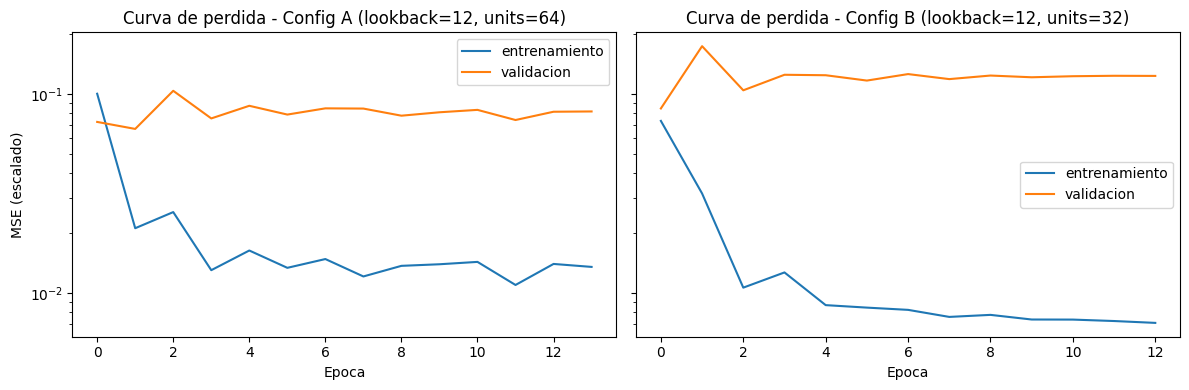

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, (_, fila) in zip(axes, mejores.iterrows()):
    h = predicciones[fila["config"]]["historia_fit"]
    ax.plot(h["loss"], label="entrenamiento")
    ax.plot(h["val_loss"], label="validacion")
    ax.set_title(f"Curva de perdida - Config {fila['config']} "
                 f"(lookback={int(fila['lookback'])}, units={int(fila['units'])})")
    ax.set_xlabel("Epoca")
    ax.set_yscale("log")
    ax.legend()
axes[0].set_ylabel("MSE (escalado)")
plt.tight_layout()
plt.show()

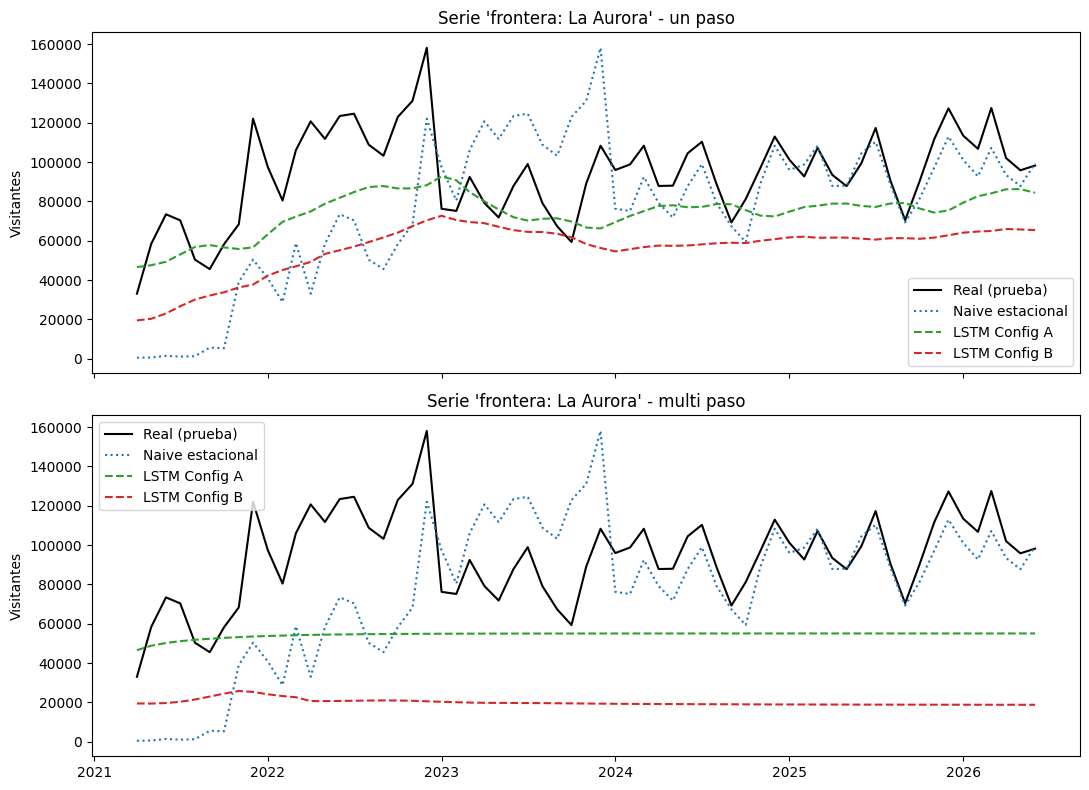

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
colores = {"A": "tab:green", "B": "tab:red"}

for ax, modo in zip(axes, ["un_paso", "multi_paso"]):
    ax.plot(test.index, test.values, color="black", lw=1.5, label="Real (prueba)")
    ax.plot(test.index, naive.values, color="tab:blue", ls=":", label="Naive estacional")
    for config in predicciones:
        ax.plot(test.index, predicciones[config][modo], ls="--",
                color=colores[config], label=f"LSTM Config {config}")
    ax.set_title(f"Serie '{SERIE}' - {modo.replace('_', ' ')}")
    ax.set_ylabel("Visitantes")
    ax.legend()
plt.tight_layout()
plt.show()

In [10]:
un_paso = (evaluacion[evaluacion["modo"] == "un paso"]
           .sort_values("RMSE").reset_index(drop=True))
ganador = un_paso.iloc[0]
print("Ranking por RMSE de prueba (prediccion a un paso):")
print(un_paso[["config", "RMSE", "MAE", "MAPE %"]].to_string(index=False))
print()
print(f"Mejor modelo para la serie '{SERIE}': Config {ganador['config']} "
      f"con RMSE = {ganador['RMSE']:,.0f}, MAE = {ganador['MAE']:,.0f}, "
      f"MAPE = {ganador['MAPE %']:.1f}%")

Ranking por RMSE de prueba (prediccion a un paso):
  config         RMSE          MAE    MAPE %
       A 27482.540733 22922.918382 22.846553
naive-12 37367.263127 29403.871874 34.665371
       B 42920.664879 38026.405744 38.635982

Mejor modelo para la serie 'frontera: La Aurora': Config A con RMSE = 27,483, MAE = 22,923, MAPE = 22.8%


## 6. Selección del mejor modelo y discusión

Criterios de selección: se comparan las dos configuraciones (ya tuneadas) por
sus métricas sobre la prueba, dando prioridad al **RMSE de la predicción a un
paso** — la misma métrica y modalidad con la que se eligió el mejor modelo en
el Laboratorio 1, lo que hará comparable esta selección con la de SARIMA en la
entrega final. El MAE y el MAPE se reportan como métricas de apoyo, y el
pronóstico multi-paso muestra cómo se degrada cada configuración cuando se
alimenta de sus propias predicciones.

Observaciones:

- La tabla de la sección 5 muestra qué configuración predijo mejor la prueba y
  si ambas superan la línea base naive estacional.
- Las curvas de pérdida permiten verificar que el early stopping cortó antes
  del sobreajuste (la pérdida de validación deja de bajar mientras la de
  entrenamiento sigue cayendo).
- En el pronóstico multi-paso el error se acumula: es esperable que las curvas
  se alejen de la serie real conforme avanza el horizonte de 63 meses.

La comparación formal contra el mejor modelo SARIMA del Laboratorio 1 (punto
1.4 del enunciado) queda para la entrega final.

## 7. Comparación con el mejor modelo del Laboratorio 1

En el Laboratorio 1 el modelo seleccionado para la serie frontera La Aurora fue el
**SARIMA(0,1,1)(1,1,0)₁₂ sobre la serie en logaritmo**, elegido por su desempeño en la predicción
a un paso sobre la prueba (sección 8 de `modelado-fronteras.ipynb` del Laboratorio 1): MAE de
24,747 y RMSE de 45,742 visitantes. Como la partición de entrenamiento y prueba es exactamente la
misma en ambos laboratorios, las métricas son directamente comparables.

Criterios de comparación: misma prueba (2021-04 a 2026-06), misma modalidad (predicción a un paso
con historia real) y mismas métricas en visitantes reales. El MAPE del SARIMA no se reportó en el
Laboratorio 1, por lo que la comparación se hace con MAE y RMSE.

In [11]:
lab1_sarima = {"RMSE": 45742.0, "MAE": 24747.0}

lstm_1p = evaluacion[(evaluacion["modo"] == "un paso")
                     & (evaluacion["config"].isin(["A", "B"]))]
comparacion = pd.DataFrame([
    {"modelo": "SARIMA(0,1,1)(1,1,0)12 en log (Lab 1)", **lab1_sarima},
    *[{"modelo": f"LSTM Config {r['config']} (Lab 2)",
       "RMSE": r["RMSE"], "MAE": r["MAE"]} for _, r in lstm_1p.iterrows()],
    {"modelo": "Naive estacional (referencia)",
     "RMSE": base["RMSE"], "MAE": base["MAE"]},
]).sort_values("MAE").reset_index(drop=True)
comparacion.round(0)

,modelo,RMSE,MAE
0,LSTM Config A (Lab 2),27483.0,22923.0
1,"SARIMA(0,1,1)(1,1,0)12 en log (Lab 1)",45742.0,24747.0
2,Naive estacional (referencia),37367.0,29404.0
3,LSTM Config B (Lab 2),42921.0,38026.0


### Conclusión de la comparación

A diferencia de la serie total, aquí el resultado es unánime y favorece a la red.

- **Por MAE** (error absoluto típico mes a mes) el LSTM Config A gana: 22,923 contra 24,747 del
  SARIMA. En el mes promedio la red se equivoca un poco menos.
- **Por RMSE** (que castiga más los errores grandes) el LSTM Config A gana con holgura: 27,483
  contra 45,742 del SARIMA. La diferencia es grande y viene de los primeros meses de la
  reapertura, donde el SARIMA arrastraba todavía el régimen del cierre y cometía errores extremos
  que la red no comete.

Manteniendo el criterio de selección del Laboratorio 1 —menor MAE a un paso, que refleja el uso
operativo mensual— **el LSTM Config A es el mejor modelo para La Aurora**, superando al SARIMA en
las dos métricas. Es el caso contrario al de la serie total, donde el SARIMA conservó el primer
lugar. La diferencia tiene sentido: La Aurora es la serie aérea, con un calendario estacional
limpio y regular que la red aprende bien, mientras que el SARIMA sufría con la transición abrupta
de la reapertura. Config B (bidireccional) queda por debajo incluso de la línea base naive, así
que la ventaja es específica de Config A, no de las redes en general. El costo es que el LSTM
requirió una rejilla de 16 combinaciones y no es interpretable en componentes como el SARIMA.